# ResistFlow - Demo Notebook

This notebook demonstrates the ResistFlow simulation framework end to end.

**Structure:**
1. Setup
2. Illustrative scenario comparison
3. MalariaGEN data fetching
4. Automatic parameter estimation
5. Burkina Faso validation (endpoint)
6. Cameroon validation (trajectory)

In [1]:
import malariagen_data

from resistflow.simulation.wright_fisher import simulate
from resistflow.scenarios.presets import get_scenario
from resistflow.visualization.plots import plot_trajectories, plot_scenario_comparison
from resistflow.data.malariagen import fetch_allele_frequency
from resistflow.analysis.parameter_estimation import get_or_estimate_fitness_parameters

### shared params

In [2]:
N = 10_000
n_generations = 80   # 8 years at 10 generations per year
n_replicates = 20
generations_per_year = 10

## 1. Illustrative scenario comparison

Runs three intervention scenarios initialized from p₀ = 0.24 
(approximate West African baseline frequency for Vgsc L995F).

Fitness parameters are derived from published selection coefficient 
estimates for Vgsc L995F (s ≈ 0.175, h ≈ 0.9; Clarkson et al. 2021).
Reduced coverage modeled as 50% exposure weighting.

These scenarios are illustrative - they show how different 
intervention assumptions affect resistance spread, not predictions 
for a specific population.

In [3]:
results = {}
for scenario_name in ["baseline", "continuous_pressure", "reduced_coverage"]:
    params = get_scenario(scenario_name)
    results[scenario_name] = simulate(
        p0=0.24,
        N=N,
        n_generations=n_generations,
        w_AA=params["w_AA"],
        w_Aa=params["w_Aa"],
        w_aa=params["w_aa"],
        n_replicates=n_replicates,
    )

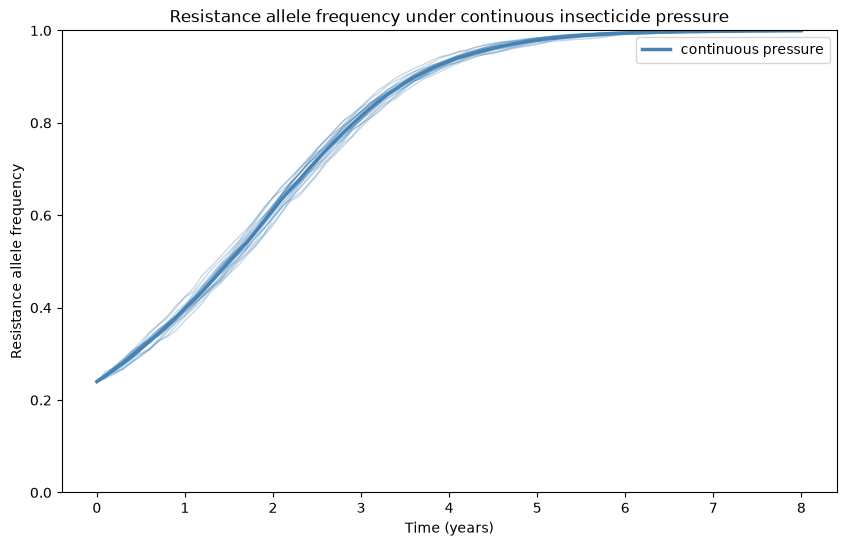

In [4]:
ax = plot_trajectories(
    trajectories=results["continuous_pressure"],
    generations_per_year=generations_per_year,
    title="Resistance allele frequency under continuous insecticide pressure",
    scenario_label="continuous pressure",
)

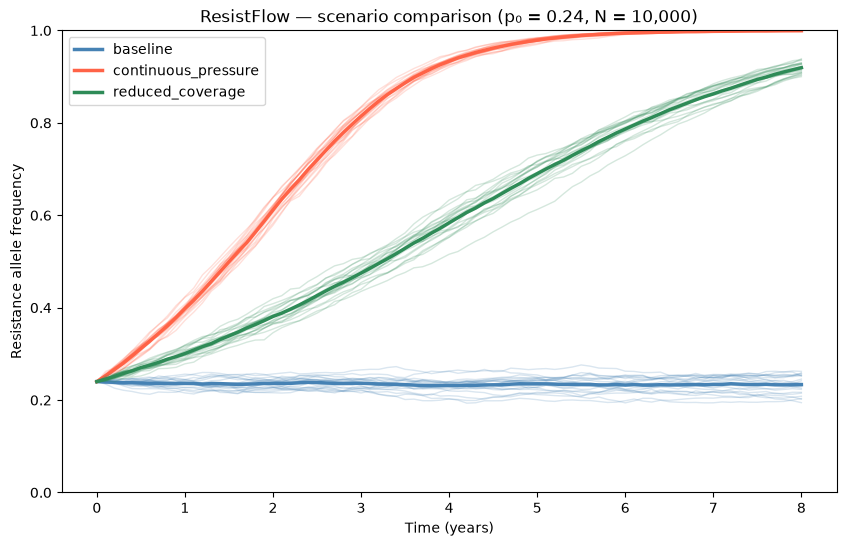

In [5]:
fig = plot_scenario_comparison(
    results_by_scenario=results,
    generations_per_year=generations_per_year,
    title="ResistFlow — scenario comparison (p₀ = 0.24, N = 10,000)",
)

## 2. MalariaGEN data fetching

Fetches real observed Vgsc L995F frequencies from MalariaGEN Ag3 
(release 3.0) for Burkina Faso and Cameroon, An. gambiae.

Note: L995F in MalariaGEN numbering corresponds to Vgsc-1014F 
in the conventional kdr literature.

In [6]:
# Burkina Faso — 2 time points (2004, 2012)
p0_bf = fetch_allele_frequency(
    aa_change="L995F", country="Burkina Faso",
    year=2004, species="gambiae",
)
p_2012_bf = fetch_allele_frequency(
    aa_change="L995F", country="Burkina Faso",
    year=2012, species="gambiae",
)

# Cameroon — 3 time points (2005, 2009, 2013)
p0_cam = fetch_allele_frequency(
    aa_change="L995F", country="Cameroon",
    year=2005, species="gambiae",
)
p_2009_cam = fetch_allele_frequency(
    aa_change="L995F", country="Cameroon",
    year=2009, species="gambiae",
)
p_2013_cam = fetch_allele_frequency(
    aa_change="L995F", country="Cameroon",
    year=2013, species="gambiae",
)

print(f"Burkina Faso - 2004: {p0_bf:.3f} | 2012: {p_2012_bf:.3f}")
print(f"Cameroon     - 2005: {p0_cam:.3f} | 2009: {p_2009_cam:.3f} | 2013: {p_2013_cam:.3f}")

Load SNP genotypes:   0%|          | 0/73 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/5 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/9675 [00:00<?, ?it/s]

Load SNP genotypes:   0%|          | 0/73 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/5 [00:00<?, ?it/s]

...

Compute SNP effects:   0%|          | 0/15301 [00:00<?, ?it/s]

Load SNP genotypes:   0%|          | 0/97 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/7 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/15301 [00:00<?, ?it/s]

Burkina Faso - 2004: 0.077 | 2012: 1.000
Cameroon     - 2005: 0.202 | 2009: 0.523 | 2013: 0.933


## 3. Automatic parameter estimation

Fitness parameters are estimated automatically from the observed 
temporal data using Nelder-Mead optimization (scipy).

The optimizer finds w_Aa and w_aa values that minimize the 
difference between the simulated mean trajectory and observed 
frequencies at each time point.

Results are cached at ~/.resistflow/params_cache.json - 
subsequent runs load from cache instantly without re-running 
the optimizer.

In [7]:
params_bf = get_or_estimate_fitness_parameters(
    p0=p0_bf,
    observed_years=[8],
    observed_frequencies=[p_2012_bf],
    country="BurkinaFaso",
    aa_change="L995F",
    species="gambiae",
    n_chromosomes=198,
)
print(f"Burkina Faso: {params_bf}")

params_cam = get_or_estimate_fitness_parameters(
    p0=p0_cam,
    observed_years=[4, 8],
    observed_frequencies=[p_2009_cam, p_2013_cam],
    country="Cameroon",
    aa_change="L995F",
    species="gambiae",
)
print(f"Cameroon: {params_cam}")

Estimating parameters for BurkinaFaso_gambiae_L995F_6a51cca5 — this may take a minute...
Parameters estimated and cached for BurkinaFaso_gambiae_L995F_6a51cca5.
Burkina Faso: {'w_AA': 1.0, 'w_Aa': 0.8874, 'w_aa': 0.8499, 'optimization_success': True, 'final_error': 0.0, 'identifiable': False, 's_min': 0.1501, 'dominance_h_assumed': 0.25, 'fitting_target': 0.984984, 'n_chromosomes': 198, 's_min_range': (0.1485, 0.1776), 'h_range_swept': (0.05, 0.65), 'note': 'Data do not uniquely identify fitness parameters — observations insufficient to constrain trajectory shape. Reporting the minimum selection coefficient (s_min=0.1501) assuming dominance h=0.25 (Lynd et al. 2010), fitted to a target of 0.984984 derived as the 95% binomial lower bound from n=198 sampled chromosomes. The bound is stable across dominance: sweeping h from 0.05 to 0.65 gives s_min between 0.1485 and 0.1776.'}
Estimating parameters for Cameroon_gambiae_L995F_9af1fe99 — this may take a minute...
Parameters estimated and ca

## 4. Burkina Faso validation - endpoint

Initializes from the real 2004 Ag3 frequency (7.7%) and simulates 
forward 8 years. Validates against the observed 2012 frequency (100%).

Limitation: only two data points available for Burkina Faso gambiae 
in Ag3 release 3.0 (2004 and 2012). The optimizer matches the 
endpoint but the trajectory shape is unconstrained. This is an 
endpoint validation, not a full trajectory validation.

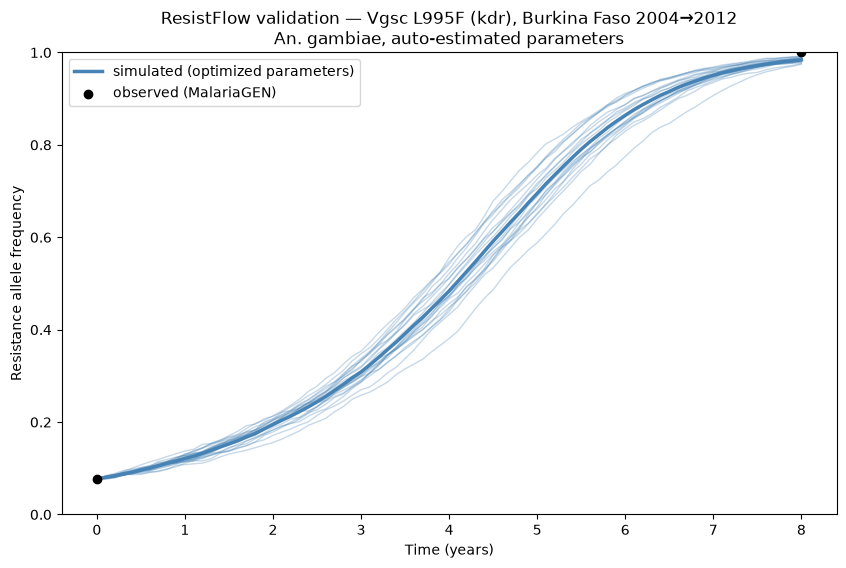

In [8]:
trajectories_bf = simulate(
    p0=p0_bf,
    N=N,
    n_generations=n_generations,
    w_AA=params_bf["w_AA"],
    w_Aa=params_bf["w_Aa"],
    w_aa=params_bf["w_aa"],
    n_replicates=n_replicates,
)

ax = plot_trajectories(
    trajectories=trajectories_bf,
    generations_per_year=generations_per_year,
    title="ResistFlow validation — Vgsc L995F (kdr), Burkina Faso 2004→2012\nAn. gambiae, auto-estimated parameters",
    scenario_label="simulated (optimized parameters)",
    observed_points={"year": [0, 8], "frequency": [p0_bf, p_2012_bf]},
)

## 5. Cameroon validation - trajectory

Initializes from the real 2005 Ag3 frequency (20.2%) and simulates 
forward 8 years. Validates against observed frequencies at both 
2009 (52.3%) and 2013 (93.3%).

Three time points constrain the trajectory shape - this is a 
full trajectory validation, not just an endpoint match.

The auto-estimated parameters (w_Aa=0.926, w_aa=0.911) suggest 
weaker selection pressure in Cameroon than Burkina Faso, consistent 
with regional variation in pyrethroid use intensity.

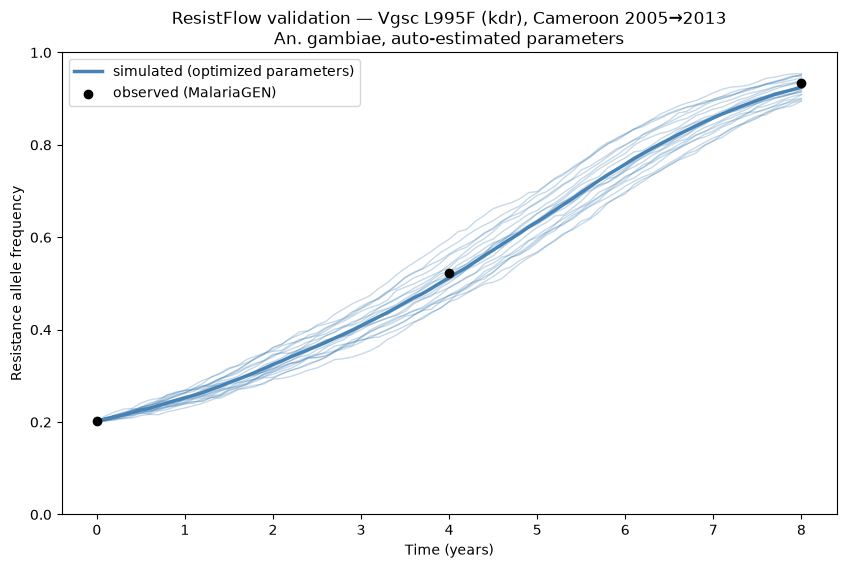

In [9]:
trajectories_cam = simulate(
    p0=p0_cam,
    N=N,
    n_generations=n_generations,
    w_AA=params_cam["w_AA"],
    w_Aa=params_cam["w_Aa"],
    w_aa=params_cam["w_aa"],
    n_replicates=n_replicates,
)

ax = plot_trajectories(
    trajectories=trajectories_cam,
    generations_per_year=generations_per_year,
    title="ResistFlow validation — Vgsc L995F (kdr), Cameroon 2005→2013\nAn. gambiae, auto-estimated parameters",
    scenario_label="simulated (optimized parameters)",
    observed_points={
        "year": [0, 4, 8],
        "frequency": [p0_cam, p_2009_cam, p_2013_cam],
    },
)

## Notes and limitations

- Single-locus model: does not account for epistasis or linkage 
  with other resistance loci
- Constant selection pressure: does not model seasonal variation 
  or changes in insecticide use over time
- No spatial structure: populations treated as panmictic
- Parameter estimation uses point estimates only - no uncertainty 
  quantification. Bayesian inference is the recommended next step.
- Burkina Faso trajectory shape is unconstrained due to limited 
  temporal sampling in Ag3 release 3.0

**Future work:** Bayesian parameter estimation, multi-locus 
simulation, spatial structure, additional countries and variants.